## Part I: Getting to Know Graphs
### What is a graph?

A graph is a mathematical structure G=(V,E) where V is the set of vertices or nodes, and E is the set of edges or links connecting pairs of vertices(Ajorlou, 2018). Graphs represent objects and the relationships between them. An example of this is in a student collaboration network, each vertex represents a student, and an edge connects two students who have worked on a project together.

A graph is usually drawn using points for vertices and lines for edges. However, the connections matter more than the positions of the points. Moving the points without changing their connections still represents the same graph. In graph theory, a graph descibes a network of relationships. This is different than a graph of a function which shows how one numerial variable changes with another. 

When describing a network, we also need to specify which kinds of connections are allowed. A simple graph has no self-loops, which are edges connecting a vertex to itself, and no multiple edges between the same pair of vertices. More general graphs can allow these features, depending on the relationships being modeled(Ajorlou, 2018).

### Vertices and Edges

To describe the connections precisely, graph theory uses the terms adjacency and incidence. Two vertices are adjacent(or neighbors) when an edge joins them. An edge is incident to each vertex it connects, and these vertices are called its endpoints. Adjacency describes a relationship between two vertices, while incidence describes a relationship between an edge and vertex (Ajorlou, 2018).

The neighborhood of a vertex contains all the vertices directly connected to it by an edge. For examnple, if B is connected to A and C, its neighborhood is {A,C}. Two edges can also share an endpoint. The edges {A,B} and {B,C} both connect to B, so B is their shared endpoint(Ajorlou, 2018).

In the vertex set V = {A,B,C,D} and the edge set E = {{A,B},{B,C}}. This graph has four vertices and two edges. The edge {A,B} has endpoints A and B, while the {B,C} has endpoints B and C. Also, Vertex D belongs to the graph even though no edge connects it to another vertex, so it is a isolated vertex.

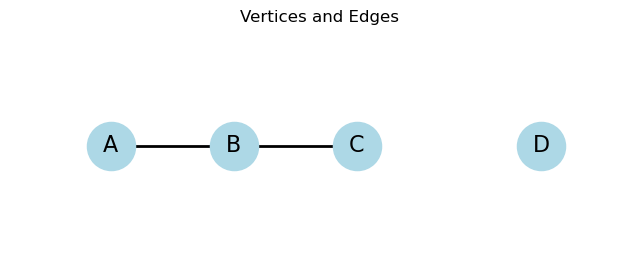

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(["A", "B", "C", "D"])
G.add_edges_from([("A", "B"), ("B", "C")])

positions = {"A": (0,0), "B": (1,0), "C":(2,0), "D": (3.5,0)}
plt.figure(figsize = (8,3))
nx.draw_networkx(G, pos = positions, node_color = "lightblue", node_size = 1200, font_size= 16, width = 2)
plt.title("Vertices and Edges")
plt.margins(0.2)
plt.axis("off")
plt.show()

Figure 1: A graph with four vertices and two edges. The two edges share endpoint B, while D is isolated. 

From the figure, the neighborhood of B is {A,C}, while the neighborhood of A is {B}. Vertex D has an empty neighborhood since it has no incident edges. D still belongs to the vertex set, showing that a vertex can exist in a graph without having any connections. 

### Directed and Undirected graphs

An undirected graph has edges without direction. An edge connecting A and B represents the same connections from either endpoint is drawn as a line without an error(Sedgewick & Wayne, n.d). An example of this a collaboration between two students that can be modeled as an undirected relationship because both students participate in the same connection.

A directed graph which is also called a digraph, has edges with a specific direction. These edges are drawn as arrows. An arrow from A to B represents a connection from A to B, but it doesn't automatically mean that there is a connection from B to A. Also, A can point to B, and B can point to A, but they are two separate directed edges(Nykamp,n.d). Links between web pages can illustrate why direction matters. One page can link to another without receiving a link back. A directed graph shows which page the link comes from and which page it points to (Nykamp, n.d.). 

To compare the two types, consider the vertices A, B, and C arranged in a triangle. In the undirected example, edges connect A to B and B to C,and C to A without arrows. While in the directed example, arrows point from A to B, B to C, and C to A. 

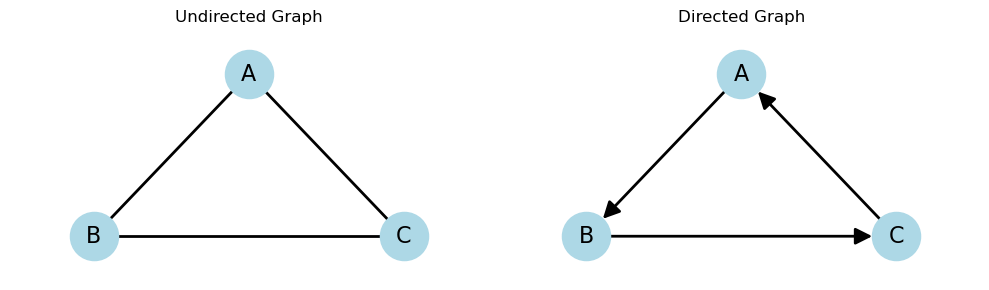

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

undirected = nx.Graph()
undirected.add_edges_from([("A", "B"), ("B", "C"), ("C", "A")])

directed = nx.DiGraph()
directed.add_edges_from([("A", "B"), ("B", "C"), ("C","A")])

positions = {"A": (0,1), "B": (-1,-0.5), "C": (1,-0.5)}
fig, axes = plt.subplots(1, 2,figsize = (10, 3)) 

nx.draw_networkx( undirected, pos = positions, ax = axes[0], node_color = "lightblue", node_size = 1200, font_size = 16, width = 2)
axes[0].set_title("Undirected Graph")

nx.draw_networkx(directed, pos = positions, ax = axes[1], node_color = "lightblue",node_size = 1200, font_size = 16, width = 2, arrows = True, arrowsize = 25)

axes[1].set_title("Directed Graph")

for ax in axes:
    ax.margins(0.2)
    ax.axis("off")

plt.tight_layout()
plt.show()


Figure 2: Undirected and directed graphs with three vertices and three edges each. The undirected graph has no arrows, while the directed graph has arrows from A to B, B to C, and C to A.

Both graphs connect the same pairs of vertices, but direction changes how the connections can be followed. In the undirected graph, the edge between A and C can be followed either way. However in the directed graph, the edge points only from C to A. To reach C from A while following the arrows, we must go through B. 

### Weighted and Unweighted graphs

An unweighted graph records whether a connection exists without assigning a numerical weight to each edge. A weighted graph adds a number to each edge to describe something about that connection.Depending on the model, weights might represent distance, travel time, cost, or the strength of an interaction(Ajorlou, 2018; Nykamp, n.d.).

Each weight needs a clear meaning. A larger number could indicate a longer journey in a transportation network or a stronger interaction in a social network. Therefore, larger weights do not always mean better connections.

For an example, consider three locations labeled A, B, and C. All three pairs have a direct route. In the unweighted graph, the edges show only the routes. In the weighted graph, suppose the travel times are 4 minutes between A and B, 3 minutes between B and C, and 10 minutes between A and C.

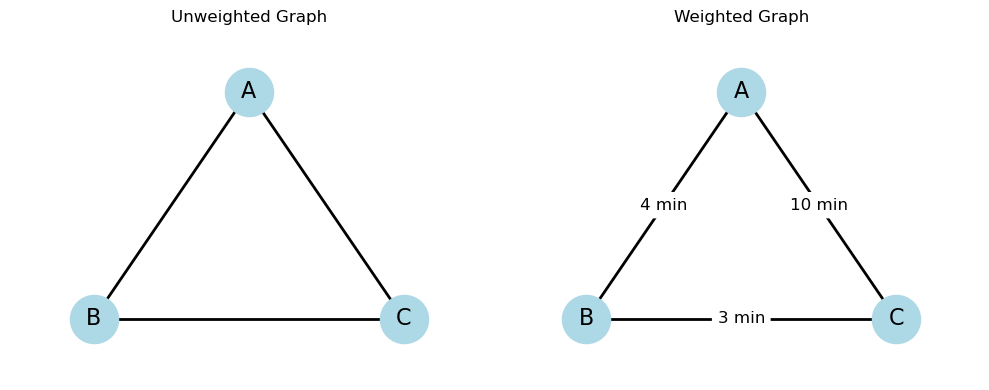

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

unweighted = nx.Graph()
unweighted.add_edges_from([("A", "B"), ("B", "C"), ("C", "A")])

weighted = nx.Graph()
weighted.add_weighted_edges_from([("A", "B", 4), ("B", "C", 3), ("A", "C", 10)])

positions = {"A": (0,1), "B": (-1,-0.5), "C": (1,-0.5)}
fig, axes = plt.subplots(1, 2,figsize = (10, 4)) 

for graph, ax in zip([unweighted, weighted], axes):
    nx.draw_networkx(graph, pos = positions, ax = ax, node_color = "lightblue", node_size = 1200, font_size = 16, width = 2)
    ax.margins(0.2)
    ax.axis("off")
axes[0].set_title("Unweighted Graph")
axes[1].set_title("Weighted Graph")

edge_labels = {(u,v) : f"{data['weight']} min"
               for u, v, data in weighted.edges(data = True)}

nx.draw_networkx_edge_labels(weighted, pos= positions, edge_labels = edge_labels, ax = axes[1], font_size = 12, rotate = False)

plt.tight_layout()
plt.show()

    

                                  

Figure 3: Unweighted and weighted graphs with the same three verties adn edges. In the weighted graph, the edge labels represent travel times of 4, 3, 10 minutes.

In the weighted example, traveling directly from A to C takes 10 minutes, while traveling through B takes 7 minutes( 4+ 3). Although the route through B uses more edges, it takes less time. This shows how weights provide information that the unweighted graph does not record. 

Direction and weight are separate features. Both graphs in Figure 3 are undirected, but directed graphs can also have weights, such as one-way roads labeled with travel times.

## References

Ajorlou, A. (2018). Lecture 2: Introduction to graph theory. MIT OpenCourseWare.

Nykamp, D.Q.(n.d.). An introduction to networks. Math insight.
https://mathinsight.org/network_introduction

Sedgewick, R., & Wayne, K.(n.d.). Undirected graphs. Algorithms, 4th edition.
https://algs4.cs.princeton.edu/41graph/


